# StoreType 'c'

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and Preprocessing

In [16]:
train_df = pd.read_csv('../train.csv', low_memory=False)
store_df = pd.read_csv('../store.csv', low_memory=False)

# Merge datasets
df = pd.merge(train_df, store_df, on='Store', how='inner')

# Filter for StoreType 'c'
df_c = df[df['StoreType'] == 'c'].copy()
df_c['Date'] = pd.to_datetime(df_c['Date'])
df_c.sort_values(['Store', 'Date'], inplace=True)
print(f"Shape of StoreType 'c' data: {df_c.shape}")

Shape of StoreType 'c' data: (136840, 18)


## 2. Assortment Analysis (EDA)
Here we analyze how different assortments impact sales and customers for StoreType c.

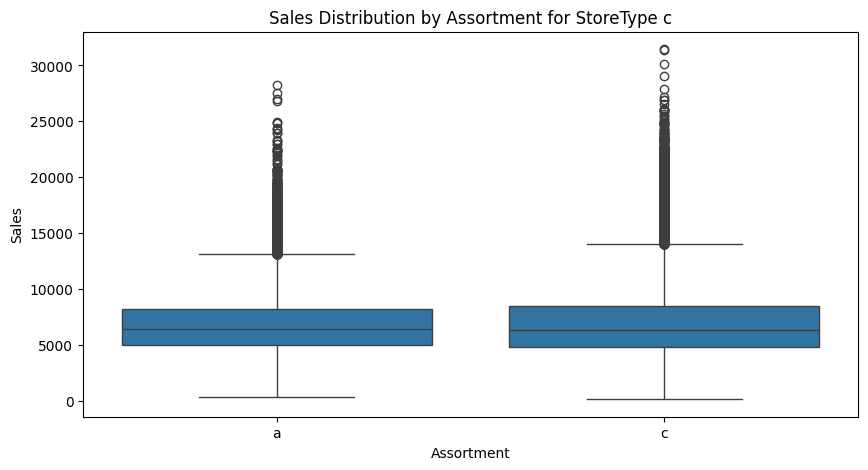

,Sales,Customers
Assortment,,
a,6834.931456,839.862827
c,7037.525130,789.211055


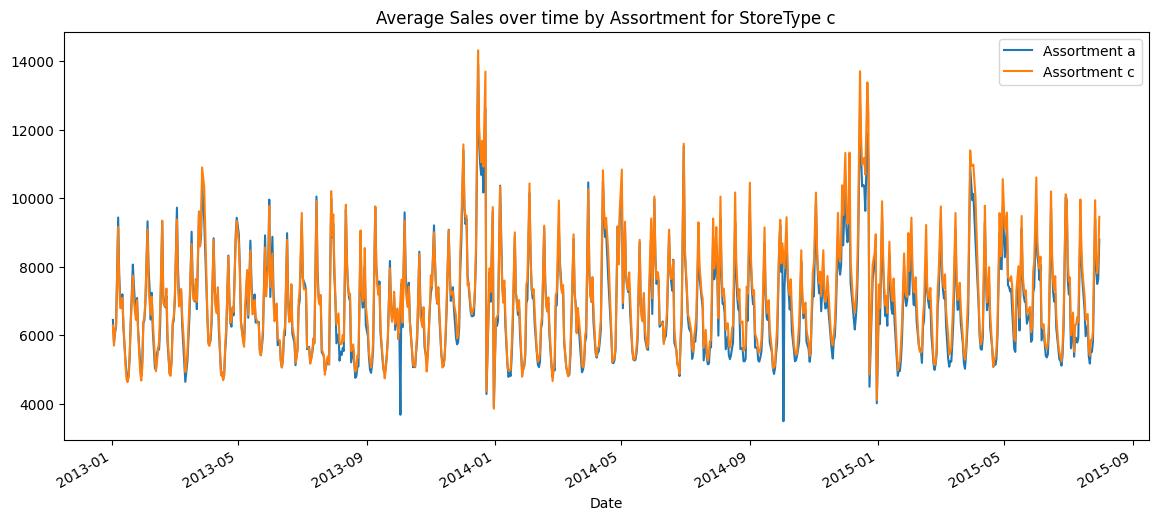

In [17]:
# Sales distribution by Assortment
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_c[df_c['Sales'] > 0], x='Assortment', y='Sales')
plt.title('Sales Distribution by Assortment for StoreType c')
plt.show()

# Average Sales and Customers by Assortment
assortment_stats = df_c[df_c['Open'] == 1].groupby('Assortment')[['Sales', 'Customers']].mean()
display(assortment_stats)

# Time Series of Sales by Assortment
plt.figure(figsize=(14, 6))
for ast in df_c['Assortment'].unique():
    temp = df_c[(df_c['Assortment'] == ast) & (df_c['Open'] == 1)]
    temp.groupby('Date')['Sales'].mean().plot(label=f'Assortment {ast}')
plt.title('Average Sales over time by Assortment for StoreType c')
plt.legend()
plt.show()

## 3. Feature Engineering

In [18]:
# 3.1 Date features
df_c['Year'] = df_c['Date'].dt.year
df_c['Month'] = df_c['Date'].dt.month
df_c['Day'] = df_c['Date'].dt.day
df_c['WeekOfYear'] = df_c['Date'].dt.isocalendar().week.astype(int)

# 2.2 Competition Distance Imputation
df_c['CompetitionDistance'].fillna(df_c['CompetitionDistance'].median(), inplace=True)

# 2.3 Time since competition opened
df_c['CompetitionOpenSinceMonth'].fillna(0, inplace=True)
df_c['CompetitionOpenSinceYear'].fillna(0, inplace=True)
def calc_comp_months(row):
    if row['CompetitionOpenSinceYear'] == 0: return 0
    return 12 * (row['Year'] - row['CompetitionOpenSinceYear']) + (row['Month'] - row['CompetitionOpenSinceMonth'])
df_c['CompetitionOpenMonths'] = df_c.apply(calc_comp_months, axis=1)
df_c['CompetitionOpenMonths'] = df_c['CompetitionOpenMonths'].apply(lambda x: x if x > 0 else 0)

# 2.4 Time series features (Lags and Rolling) for Sales (grouped by store)
# Note: In a real predictive scenario, we only lag target variables.
df_c['Sales_Lag1'] = df_c.groupby('Store')['Sales'].shift(1)
df_c['Sales_Lag7'] = df_c.groupby('Store')['Sales'].shift(7)
df_c['Sales_RollMean7'] = df_c.groupby('Store')['Sales_Lag1'].transform(lambda x: x.rolling(7).mean())

# Drop NAs created by lags
df_model = df_c.dropna().copy()
# Only model for days when the store is open
df_model = df_model[df_model['Open'] == 1]
print(f"Modeling data shape: {df_model.shape}")

Modeling data shape: (55840, 26)


## 4. Data Splitting

In [19]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Features
categorical_cols = ['StateHoliday', 'Assortment']
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

features = ['Store', 'DayOfWeek', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 
            'CompetitionOpenMonths', 'Year', 'Month', 'Day', 'WeekOfYear', 
            'Sales_Lag1', 'Sales_Lag7', 'Sales_RollMean7'] + [c for c in df_model.columns if 'StateHoliday_' in c or 'Assortment_' in c]

X = df_model[features]
y = df_model['Sales']

# Chronological split (prevent data leakage)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(X_train.shape, X_test.shape)

(44672, 15) (11168, 15)


## 5. Modeling and Hyperparameter Tuning
We will compare Linear Regression, Random Forest, and XGBoost.

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

results = {}

def evaluate(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    results[model_name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"{model_name} - RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}")

In [21]:
# 4.1 Linear Regression Baseline
lr = LinearRegression()
lr.fit(X_train, y_train)
evaluate('Linear Regression', y_test, lr.predict(X_test))

Linear Regression - RMSE: 1694.85, MAE: 1220.10, R2: 0.4812


In [22]:
# 4.2 Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
evaluate('Random Forest (Default)', y_test, rf.predict(X_test))

Random Forest (Default) - RMSE: 1181.56, MAE: 773.90, R2: 0.7479


In [23]:
# 4.3 XGBoost Regressor with RandomizedSearchCV for Tuning
xgb = XGBRegressor(random_state=42, objective='reg:squarederror')

# Define parameter grid
param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_distributions,
    n_iter=10,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting XGBoost Hyperparameter Tuning...")
random_search.fit(X_train, y_train)

print(f"Best parameters found: {random_search.best_params_}")
best_xgb = random_search.best_estimator_

evaluate('XGBoost (Tuned)', y_test, best_xgb.predict(X_test))

Starting XGBoost Hyperparameter Tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters found: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
XGBoost (Tuned) - RMSE: 1103.43, MAE: 791.26, R2: 0.7801


## 6. Model Comparison and Feature Importance

,RMSE,MAE,R2
XGBoost (Tuned),1103.430673,791.259155,0.780094
Random Forest (Default),1181.556946,773.897065,0.747852
Linear Regression,1694.853679,1220.100779,0.481187


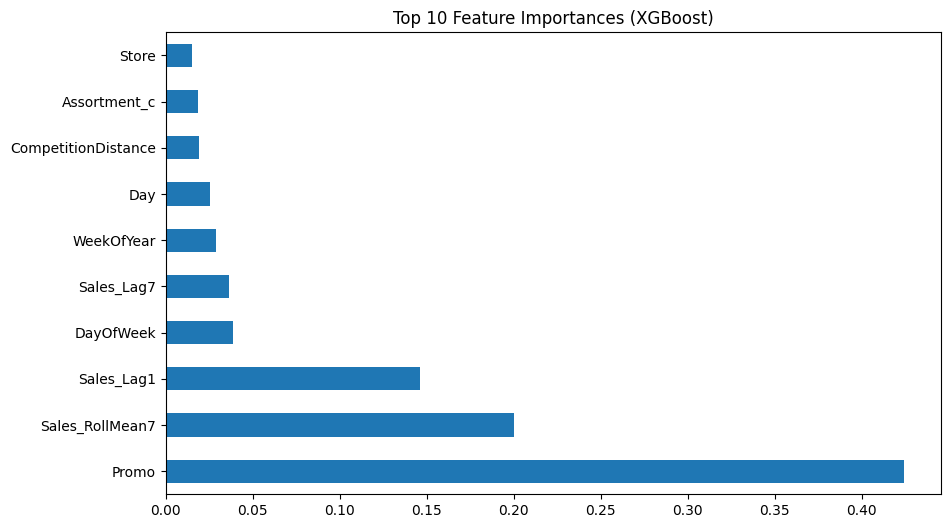

In [24]:
# Display Results
res_df = pd.DataFrame(results).T
display(res_df.sort_values('RMSE'))

# Feature Importance of best model
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(best_xgb.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.show()